# Discrete State Space
## Numerical Experiments

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Literal, Optional, Tuple, Union
import sys, time, logging, importlib
from pathlib import Path

import math
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

ROOT = Path('..').resolve()
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from mfc.algorithms import SimplexPerturbedMFREINFORCE
from mfc.environments import TwoStateMFC, TwoStateConfig

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64
torch.set_default_dtype(DTYPE)

def set_seed(seed: int) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)

set_seed(0)
print(device)

cuda


## 1. Two-State Two-Action Toy Problem [Meunier2026][17]
References:
[17] Haotian Gu, Xin Guo, Xiaoli Wei, and Renyuan Xu. Dynamic programming principles for mean-field controls with learning. Operations Research, 71(4):1040–1054, 2023
[24] Diederik P Kingma. Adam: A method for stochastic optimization. arXiv preprint arXiv:1412.6980, 2014.


The action space is $\mathcal A=\{\mathrm{ST}, \mathrm{MV}\}$ and the state space is $\mathcal X = \{0, 1\}$. The transition kernel is defined as follows: for $x\in\mathcal X, a\in\mathcal A, P(x'\mid x,a)=\lambda_x\mathbf 1_{a=\mathrm{MV}}$ if $x'\neq x$ and $P(x'\mid x,a)=1-\lambda_x\mathbf 1_{a=\mathrm{MV}}$ if $x'=x$, where $\lambda_0,\lambda_1\in(0,1)$ are fixed parameters. The running reward function is defined as
\begin{align}
    r(x,a,\mu)=r(x\mu)=\mathbf 1_{x=1} - \mu(1)^2-\lambda W_1(\mu,B),
\end{align}
where $W_1$ is the 1-Wasserstein distance, $\lambda>0$ is a fixed scalar parameter and B is a Bernoulli distribution with parameter $p$ such that $1-\lambda_0\leq p\leq \lambda_1$. The terminal reward function is $g(x,\mu)=r(x,\mu)$. Although the original problem in [17] is an infinite-horizon discounted problem, we consider here a finite-horizon version with time horizon $T$. In this setting, there exists an optimal stationary policy given by
\begin{align}
    \pi^\star(a\mid 0,\mu) &= \left(1-\frac{1-p}{\lambda_0} \right)\mathbf 1_{\{a=\mathrm{ST} \}} + \frac{1-p}{\lambda_0}\mathbf 1_{\{a=\mathrm{MV}\}}, \\
    \pi^\star(a\mid 1,\mu) &= \left(1-\frac{p}{\lambda_1} \right)\mathbf 1_{\{a=\mathrm{ST}\}} +\frac{p}{\lambda_1}\mathbf 1_{\{a=\mathrm{MV}\}}.
\end{align}

We consider the same parameters as [Meunier2026]: $T=2,\lambda_0=0.5,\lambda_1=0.8,\lambda=10,p=0.6$. This policy guarantees that, no matter the initial distribution $\mu_0$, the distribution at all time steps $t\geq1$ is $\mu_t^\star=B$.

The training and evaluation are done as follows.
For each training episode we simulate the population starting from a random initial distribution $\mu=\mathcal P(\mathcal X)^\star$ by drawing $\mu(L)\sim\mathcal U([0.1,0.9])$. Every $10$ training episodes, we freeze the policy and sample a validation episode for which we compute the population reward $V(\mu_0)$ starting from a fixed initial distribution $\mu_0=(\mu_0(0),\mu_0(1))=(0.2,0.8)$. During training, we compute $N=200$ main perturbed trajectories for MF-REINFORCE and also use an empirical unperturbed population flow estimated from simulated particles, with $n=10$ auxiliary trajectories for the population-flow sensitivity estimator. For this
first example, the policy considered is a simple static policy that outputs a $|\mathcal X|\times|\mathcal A|$ matrix corresponding to the probability of each action given each state. We make this particular choice of policy to check whether MF-REINFORCE is capable of recovering the optimal static policy given above.
We use the Adam optimizer [24] and train for $5,000$ episodes using a learning rate of $10^{-3}$. The experiments are run for $\varepsilon$ ranging in the set $\{0.2,0.5,1.0,2.0\}$.


FINDINGS:
One can see that a larger value of $\varepsilon$ leads to faster increase in the value function at first, but yields worse final policies. In particular, we see that choosing ε too large can lead to catastophic failure. To evaluate how well the learned policies match the optimal static policy $\pi^\star$, we compute the average absolute errors in the resulting estimates of $\pi(\mathrm{ST}\mid 0)$ and $\pi(\mathrm{ST}\mid 1)$ over $5$ independent training runs for each value of $\varepsilon$ considered. The results are reported in Table 1. These results match adequately with the curves of Figure 1: the smaller $\varepsilon$, the better and closer to optimal the learned policy is.

In [ ]:
# Configuration and parameters
config = TwoStateConfig(
    T = 2, # Time horizon
    lam0 = 0.5,
    lam1 = 0.8,
    lam = 10, # Fixed scalar parameter
    target_p = 0.6, # Bernoulli parameter

    # Sample mu0 with mu0(1) ~ Uniform([low, high])
    low = 0.1,
    high = 0.9,

    q_sigma = 1.0,
    q_clip = 1e-8,

    device = device,
    dtype = torch.float64,
)

N = 200     # Main perturbed trajectories for MF-REINFORCE
n = 10      # Auxiliary trajectories for population-flow sensitivity estimation
flow_particles = 200 # Particles for the empirical unperturbed population flow

lr = 1e-3   # Learning rate
n_train = 50 # Number of epochs
training_runs = 1 # Number of independent training runs for each epsilon value
validate_every = 10

epsilon_range = [0.05, 0.1, 0.2, 0.5] # Range of epsilon values to test

In [ ]:
# Training
results_exp1 = {}

for eps in epsilon_range:
    results_exp1[eps] = []
    eta_aux = eps
    eps_law = eps

    for run_idx in range(training_runs):
        env = TwoStateMFC(config)
        algorithm = SimplexPerturbedMFREINFORCE(env)

        theta = torch.nn.Parameter(torch.zeros(2, 2, dtype=config.dtype, device=config.device))
        optimizer = torch.optim.Adam([theta], lr=lr)
        fixed_mu0 = torch.tensor([0.2, 0.8], dtype=config.dtype, device=config.device)

        history: Dict[str, List[float]] = {
            "episode": [],
            "validation_value": [],
            "train_return_mean": [],
            "grad_norm": [],
            "pi_st_0": [],
            "pi_st_1": [],
            "err_pi_st_0": [],
            "err_pi_st_1": [],
        }
        
        pi_star = env.optimal_policy()

        for episode in tqdm(range(n_train)):
            # Sample mu0 with mu0(1) ~ Uniform([low, high])
            mu1 = config.low + (config.high - config.low) * torch.rand((), dtype=config.dtype, device=config.device)
            mu0 = torch.stack([1.0 - mu1, mu1])

            with torch.no_grad():
                mu_hat_flow = algorithm.estimate_population_flow(theta.detach(), mu0, flow_particles)
                D_hat = algorithm.estimate_sensitivity(theta.detach(), mu_hat_flow, eta_aux, n)
                grad_hat, diag = algorithm.gradient_estimate(theta.detach(), mu_hat_flow, D_hat, eps_law, N, baseline="batch_mean")

            optimizer.zero_grad(set_to_none=True)
            theta.grad = -grad_hat.detach().clone()
            optimizer.step()

            if episode % validate_every == 0 or episode == n_train - 1:
                with torch.no_grad():
                    val = env.exact_value(theta.detach(), fixed_mu0)
                    pi = env.policy_probs(theta.detach())

                    history["episode"].append(float(episode))
                    history["validation_value"].append(float(val.item()))
                    history["train_return_mean"].append(float(diag["mean_return"].item()))
                    history["grad_norm"].append(float(diag["grad_norm"].item()))

                    history["pi_st_0"].append(float(pi[0, 0].item()))
                    history["pi_st_1"].append(float(pi[1, 0].item()))

                    history["err_pi_st_0"].append(float(torch.abs(pi[0, 0] - pi_star[0, 0]).item()))
                    history["err_pi_st_1"].append(float(torch.abs(pi[1, 0] - pi_star[1, 0]).item()))
    
        with torch.no_grad():
            final_pi = env.policy_probs(theta.detach())
            final_value = env.exact_value(theta.detach(), fixed_mu0)

        out = {
            "seed": run_idx,
            "eps_law": eps,
            "theta": theta.detach().clone(),
            "final_policy": final_pi.detach().clone(),
            "optimal_policy": pi_star.detach().clone(),
            "final_value": float(final_value.item()),
            "history": history,
            "config": config,
            "flow_particles": flow_particles,
        }
        results_exp1[eps].append(out)
        
    print(f"=== Training completed for eps={eps} over {training_runs} runs ===")
    print("Final validation values:", [run["final_value"] for run in results_exp1[eps]])
    print("Optimal policy")
    print(results_exp1[eps][0]["optimal_policy"])
    print()

100%|██████████| 50/50 [00:31<00:00,  1.60it/s]


=== Training completed for eps=0.05 over 1 runs ===
Final validation values: [-3.6420226765438297]
Optimal policy
tensor([[0.2000, 0.8000],
        [0.2500, 0.7500]], device='cuda:0')



100%|██████████| 50/50 [00:31<00:00,  1.61it/s]


=== Training completed for eps=0.1 over 1 runs ===
Final validation values: [-3.650520766990778]
Optimal policy
tensor([[0.2000, 0.8000],
        [0.2500, 0.7500]], device='cuda:0')



100%|██████████| 50/50 [00:31<00:00,  1.59it/s]


=== Training completed for eps=0.2 over 1 runs ===
Final validation values: [-3.564069353087813]
Optimal policy
tensor([[0.2000, 0.8000],
        [0.2500, 0.7500]], device='cuda:0')



100%|██████████| 50/50 [00:30<00:00,  1.63it/s]

=== Training completed for eps=0.5 over 1 runs ===
Final validation values: [-3.3914773076682407]
Optimal policy
tensor([[0.2000, 0.8000],
        [0.2500, 0.7500]], device='cuda:0')



### Gradient sanity check

For a fixed policy parameter, we estimate $\widehat G_{\lambda,\eta,B,n}(\theta)$ with large batches using the empirical flow used by the algorithm, then compare its direction with an autograd oracle computed through the exact population flow. The primary diagnostic is cosine similarity against $\nabla_\theta J^\lambda(\theta)$; the unperturbed $\nabla_\theta J(\theta)$ is shown as a nearby reference.


In [8]:
# Gradient sanity check
sanity_eps = epsilon_range[0]
theta_check = results_exp1[sanity_eps][0]["theta"]
eps_law, eta_aux = sanity_eps, sanity_eps
n_aux: int = 1_000 # Consider bigger values for the check 
B: int = 2_000
flow_particles: int = 5_000
n_q_oracle: int = 20_000

env = TwoStateMFC(config)
algorithm = SimplexPerturbedMFREINFORCE(env)

mu0 = torch.tensor([0.2, 0.8], dtype=config.dtype, device=config.device)
theta0 = theta_check.detach().clone().to(dtype=config.dtype, device=config.device)

with torch.no_grad():
    mu_hat_flow = algorithm.estimate_population_flow(theta0, mu0, flow_particles)
    exact_flow = env.exact_population_flow(theta0, mu0)
    D_hat = algorithm.estimate_sensitivity(theta0, mu_hat_flow, eta_aux, n_aux)
    grad_hat, diag = algorithm.gradient_estimate(theta0, mu_hat_flow, D_hat, eps_law, B, baseline="batch_mean")

theta_var = theta0.detach().clone().requires_grad_(True)

# Exact perturbed value mc
mu_flow = env.exact_population_flow(theta_var, mu0)
value = torch.zeros((), dtype=theta_var.dtype, device=theta_var.device)

for t in range(env.config.T + 1):
    q_t = algorithm.sample_q_batch(n_q_oracle)
    M_t = (1.0 - eps_law) * mu_flow[t].unsqueeze(0) + eps_law * q_t
    mu1 = M_t[:, 1]
    population_penalty = (-mu1.square() - env.config.lam * torch.abs(mu1 - env.config.target_p)).mean()
    state_reward = mu_flow[t, 1]
    value = value + state_reward + population_penalty

# Exact perturbed gradient mc
(grad,) = torch.autograd.grad(value, theta_var)
J_lam, grad_J_lam = value.detach(), grad.detach()

# Exact unperturbed gradient
value = env.exact_value(theta_var, mu0)
(grad,) = torch.autograd.grad(value, theta_var)
J, grad_J = value.detach(), grad.detach()

def cosine_similarity_flat(x: torch.Tensor, y: torch.Tensor) -> float:
    denom = torch.linalg.norm(x) * torch.linalg.norm(y)
    if float(denom.item()) == 0.0:
        return float("nan")
    return float((x.flatten() @ y.flatten() / denom).item())

print("Cosine vs grad J_lambda:", cosine_similarity_flat(grad_hat, grad_J_lam))
print("Cosine vs grad J:", cosine_similarity_flat(grad_hat, grad_J))
print("Norm G_hat:", float(torch.linalg.norm(grad_hat).item()))
print("Norm grad J_lambda:", float(torch.linalg.norm(grad_J_lam).item()))
print("Norm grad J:", float(torch.linalg.norm(grad_J).item()))
print("J_lambda oracle MC:", float(J_lam.item()))
print("J oracle:", float(J.item()))
print("Empirical flow L1 error:", float(torch.abs(mu_hat_flow - exact_flow).sum().item()))

Cosine vs grad J_lambda: 0.9966177671065078
Cosine vs grad J: 0.9966128843009939
Norm G_hat: 7.545613811282221
Norm grad J_lambda: 4.532867619435929
Norm grad J: 4.747318689566278
J_lambda oracle MC: -3.452748583099221
J oracle: -3.6420226765438297
Empirical flow L1 error: 0.013973240246410612


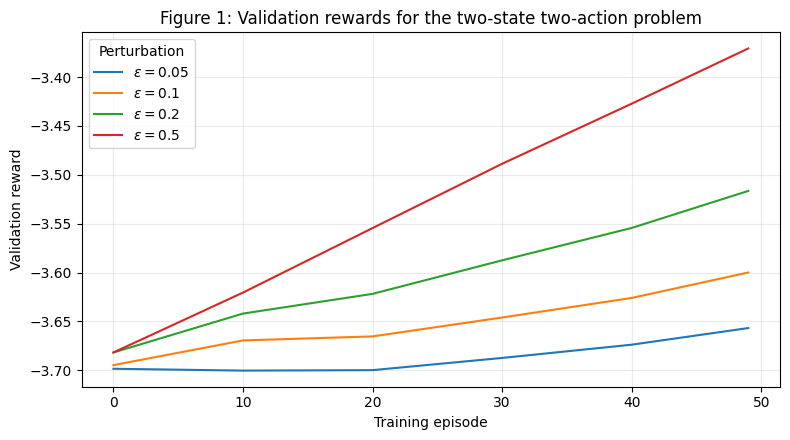

,avg_abs_err_pi(ST|0),std_abs_err_pi(ST|0),avg_abs_err_pi(ST|1),std_abs_err_pi(ST|1),avg_abs_err_policy
epsilon,,,,,
0.05,0.2955,0.0,0.2513,0.0,0.2734
0.10,0.2920,0.0,0.2547,0.0,0.2733
0.20,0.2898,0.0,0.2605,0.0,0.2751
0.50,0.2851,0.0,0.2703,0.0,0.2777


In [ ]:
# Results
fig, ax = plt.subplots(figsize=(8, 4.5))
table_rows = []
std_ddof = 1 if training_runs > 1 else 0

for eps in epsilon_range:
    runs = results_exp1[eps]

    episodes = np.asarray(runs[0]["history"]["episode"], dtype=float)
    validation_rewards = np.asarray([run["history"]["validation_value"] for run in runs], dtype=float,)
    reward_mean = validation_rewards.mean(axis=0)
    reward_std = validation_rewards.std(axis=0, ddof=std_ddof)

    ax.plot(episodes, reward_mean, label=rf"$\varepsilon={eps}$")
    ax.fill_between(episodes, reward_mean - reward_std, reward_mean + reward_std, alpha=0.18)

    pi_star = runs[0]["optimal_policy"].detach().cpu().numpy()
    final_policies = np.asarray(
        [run["final_policy"].detach().cpu().numpy() for run in runs],
        dtype=float,
    )
    st_errors = np.abs(final_policies[:, :, 0] - pi_star[:, 0])

    table_rows.append(
        {
            "epsilon": eps,
            "avg_abs_err_pi(ST|0)": st_errors[:, 0].mean(),
            "std_abs_err_pi(ST|0)": st_errors[:, 0].std(ddof=std_ddof),
            "avg_abs_err_pi(ST|1)": st_errors[:, 1].mean(),
            "std_abs_err_pi(ST|1)": st_errors[:, 1].std(ddof=std_ddof),
            "avg_abs_err_policy": st_errors.mean(axis=1).mean(),
        }
    )

ax.set_title("Figure 1: Validation rewards for the two-state two-action problem")
ax.set_xlabel("Training episode")
ax.set_ylabel("Validation reward")
ax.legend(title="Perturbation")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

table_1 = pd.DataFrame(table_rows).set_index("epsilon")
display(table_1.round(4))


## 2. Cybersecurity Example [Meunier2026][25][6]
References:
- [25] Vassili N Kolokoltsov and Alain Bensoussan. Mean-field-game model for botnet defense in cybersecurity. Applied Mathematics & Optimization, 74(3):669–692, 2016
- [6] Ren´e Carmona, Mathieu Lauri`ere, and Zongjun Tan. Model-free mean-field reinforcement learning: mean-field MDP and mean-field Q-learning. The Annals of Applied Probability, 33(6B):5334–5381, 2023

We consider a large population of computers.

Four states:
- DI: defended and infected
- DS: defended and susceptible
- UI: undefended and infected
- US: undefended and susceptible

Action space is $\mathcal A = \{0,1\}$, where $0$ means keeping the same level of protection $\mathrm D$ or $\mathrm U$, and $1$ means updating the level of protection (from $\mathrm D$ to $\mathrm U$ or vice versa).

When infected, the computer recovers at rate $q_\mathrm{rec}^D$ or $q_\mathrm{rec}^U$ depending on the level of protection. When susceptible, the computer might
be infected either directly by a hacker or by the other infected computers, at rates depending on the level of protection of the susceptible computer and the other infected computers.

Originally the problem was formulated in continuous time, and the infinitesimal generator matrix can be written, given the current distribution of the population $\mu$ and action chosen by the computer $a$, as
\begin{align}
    Q^{\mu, a} =
    \begin{pmatrix}
        \dots & q_{\mathrm{rec}}^D & \lambda a & 0 \\
        Q_{\mathrm{DS} \rightarrow \mathrm{DI}}^{\mu, a} & \dots & 0 & \lambda a \\
        \lambda a & 0 & \dots & q_\mathrm{rec}^U \\
        0 & \lambda a & Q_{\mathrm{US} \rightarrow \mathrm{UI}} & \dots  
    \end{pmatrix},
\end{align}
where
\begin{align}
    Q_{\mathrm{DS} \rightarrow \mathrm{DI}}^{\mu, a} &= v_H q_\mathrm{inf}^D + \beta_{\mathrm{DD}}\mu(\mathrm{DI}) + \beta_{\mathrm{UD}}\mu(UI), \\
    Q_{\mathrm{US} \rightarrow \mathrm{UI}}^{\mu, a} &= v_H q_\mathrm{inf}^U + \beta_\mathrm{UU}\mu(\mathrm{UI}) + \beta_\mathrm{DU}\mu(\mathrm{DI}),
\end{align}
and all instances of $\dots$ should be replaced by values to make each row sum to $0$.

Each computer incurs a cost whenever it is defended or infected. The individual cost per unit of time is given by $f(x) = k_D\mathbf 1_{x\in\{\mathrm{DI}, \mathrm{DS}\}} + k_I\mathbf 1_{x\in\{\mathrm{DI},\mathrm{UI} \}}.

The model is adapted to a discrete time setting by considering a time grid $0, \Delta t, 2\Delta t, \ldots, N_{\mathrm{epi}}\Delta t$. Between two points of the time grid, the transition matrix is given by $P_{\Delta t}^{\mu, a} = \exp(\Delta t Q^{\mu, a})$, and the running reward is $r_{\Delta t}(x, a, \mu) = r_{\Delta t}(x) = -\Delta t f(x)$.

For the numerical experiments, we use the same values for the parameters as in [Meunier2026]. The rewards are discounted by $\gamma =0.5$ and the terminal reward is taken to be the same as the running reward.

The training and evaluation are done as follows. As the transition probability is stationary and the terminal reward is the same as the step reward, the length of a training episode is taken to be $T_\mathrm{train}=3$ to mitigate the "curse of time" (cf. [Meunier2026] - Remark 3.2), and for each training episode we simulate the population starting from a random initial distribution $\mu\in \mathcal P(\mathcal X)^\star$. Every 10 training episodes, we freeze the policy and sample a validation episode of length $T_\mathrm{val}=50$, for which we compute the population reward $V(\mu_0)$ starting from a fixed initial distribution $\mu_0=(1/4, 1/4, 1/4, 1/4).
During training, the implementation below uses the same simplex-perturbed empirical-flow framework as in Problem 1. We compute $N=200$ main perturbed trajectories, estimate the unperturbed population flow from simulated particles, and use $n$ auxiliary trajectories for the population-flow sensitivity estimator. The policy is given by a 2-layer MLP, with 32 hidden units and tanh activations; it takes as input $t, \mu$ and outputs a $|\mathcal X|\times |\mathcal A|$ matrix corresponding to the probability of each action given each state.
We use the Adam optimizer with learning rate $10^{-3}$.
The experiments below use simplex perturbations $\varepsilon \in (0,1)$.

FINDINGS: We clearly see the effect of $\varepsilon$ on the variance of the overall training algorithm: the smaller the perturbation, the more erratic the gradient estimation becomes, which leads to slower convergence. Surprisingly, taking a smaller
value of epsilon does not lead to a better policy. To confirm that the policy obtained is not suboptimal, we compare the state distribution evolution under the learned policy to the results obtained in [6] with mean-field Q-learning. The resulting flow of distributions is shown in Figure 3. Clearly, we see that the qualitative behaviour of the population under the policy learned using
MF-REINFORCE eventually matches the one learned using mean-field Q-learning in [6].

### Config


In [19]:
@dataclass
class CyberConfig:
    beta_UU: float = 0.3
    beta_UD: float = 0.4
    beta_DU: float = 0.3
    beta_DD: float = 0.4
    q_rec_D: float = 0.5
    q_rec_U: float = 0.4
    q_inf_D: float = 0.4
    q_inf_U: float = 0.3
    v_H: float = 0.6
    switch_rate: float = 0.8 # Lambda
    k_D: float = 0.3
    k_I: float = 0.5
    dt: float = 0.2
    gamma: float = 0.5
    T_train: int = 3
    T_val: int = 50
    n_states: int = 4
    n_actions: int = 2
    hidden_units: int = 32
    q_sigma: float = 1.0
    q_clip: float = 1e-8
    device: torch.device = device
    dtype: torch.dtype = DTYPE


cyber_state_names = ["DI", "DS", "UI", "US"]
DI, DS, UI, US = range(4)
KEEP, UPDATE = range(2)

### Environment


In [20]:
class CyberPolicy(torch.nn.Module):
    def __init__(self, config: CyberConfig):
        super().__init__()
        self.config = config
        self.net = torch.nn.Sequential(
            torch.nn.Linear(1 + config.n_states, config.hidden_units),
            torch.nn.Tanh(),
            torch.nn.Linear(config.hidden_units, config.hidden_units),
            torch.nn.Tanh(),
            torch.nn.Linear(config.hidden_units, config.n_states * config.n_actions),
        ).to(device=config.device, dtype=config.dtype)

    def forward(self, t: int, mu: torch.Tensor) -> torch.Tensor:
        time = torch.tensor([t / max(1, self.config.T_val)], dtype=mu.dtype, device=mu.device)
        z = torch.cat([time, mu])
        return self.net(z).reshape(self.config.n_states, self.config.n_actions)

    def probs(self, t: int, mu: torch.Tensor) -> torch.Tensor:
        return torch.softmax(self.forward(t, mu), dim=-1)


class CybersecurityMFC:
    def __init__(self, config: CyberConfig):
        self.config = config
        self.n_states = config.n_states
        self.n_actions = config.n_actions
        self.reward_by_state = torch.tensor(
            [-(config.k_D + config.k_I), -config.k_D, -config.k_I, 0.0],
            dtype=config.dtype,
            device=config.device,
        ) * config.dt

    def generator(self, mu: torch.Tensor, action: int) -> torch.Tensor:
        c = self.config
        zero = torch.zeros((), dtype=mu.dtype, device=mu.device)
        sw = torch.as_tensor(c.switch_rate * float(action), dtype=mu.dtype, device=mu.device)
        q_rec_D = torch.as_tensor(c.q_rec_D, dtype=mu.dtype, device=mu.device)
        q_rec_U = torch.as_tensor(c.q_rec_U, dtype=mu.dtype, device=mu.device)
        inf_D = c.v_H * c.q_inf_D + c.beta_DD * mu[DI] + c.beta_UD * mu[UI]
        inf_U = c.v_H * c.q_inf_U + c.beta_UU * mu[UI] + c.beta_DU * mu[DI]

        return torch.stack([
            torch.stack([-(q_rec_D + sw), q_rec_D, sw, zero]),
            torch.stack([inf_D, -(inf_D + sw), zero, sw]),
            torch.stack([sw, zero, -(sw + q_rec_U), q_rec_U]),
            torch.stack([zero, sw, inf_U, -(sw + inf_U)]),
        ])

    def transition_matrix(self, mu: torch.Tensor, action: int) -> torch.Tensor:
        return torch.matrix_exp(self.config.dt * self.generator(mu, action))

    def averaged_kernel(self, policy: CyberPolicy, t: int, mu: torch.Tensor) -> torch.Tensor:
        pi = policy.probs(t, mu)
        P_keep = self.transition_matrix(mu, KEEP)
        P_update = self.transition_matrix(mu, UPDATE)
        return pi[:, KEEP].unsqueeze(1) * P_keep + pi[:, UPDATE].unsqueeze(1) * P_update

    def exact_population_flow(self, policy: CyberPolicy, mu0: torch.Tensor, horizon: int) -> torch.Tensor:
        flow = [mu0]
        for t in range(horizon):
            flow.append(flow[-1] @ self.averaged_kernel(policy, t, flow[-1]))
        return torch.stack(flow)

    def exact_value(self, policy: CyberPolicy, mu0: torch.Tensor, horizon: int) -> torch.Tensor:
        flow = self.exact_population_flow(policy, mu0, horizon)
        value = torch.zeros((), dtype=self.config.dtype, device=self.config.device)
        for t in range(horizon):
            value = value + (self.config.gamma ** t) * (flow[t] * self.reward_by_state).sum()
        value = value + (self.config.gamma ** horizon) * (flow[horizon] * self.reward_by_state).sum()
        return value

    @torch.no_grad()
    def sample_action(self, policy: CyberPolicy, t: int, state: int, mu: torch.Tensor) -> int:
        return int(torch.multinomial(policy.probs(t, mu)[state], num_samples=1).item())

    @torch.no_grad()
    def sample_next_state(self, state: int, action: int, mu: torch.Tensor) -> int:
        probs = torch.clamp(self.transition_matrix(mu, action)[state], min=0.0)
        probs = probs / probs.sum()
        return int(torch.multinomial(probs, num_samples=1).item())

    def reward(self, state: int, mu: torch.Tensor) -> torch.Tensor:
        return self.reward_by_state[state]

    def policy_score(self, policy: CyberPolicy, t: int, mu: torch.Tensor, state: int, action: int) -> torch.Tensor:
        logp = torch.log(policy.probs(t, mu)[state, action].clamp_min(1e-12))
        grads = torch.autograd.grad(logp, tuple(policy.parameters()), allow_unused=False)
        return torch.nn.utils.parameters_to_vector([g.detach() for g in grads])


### Algorithm


The cybersecurity experiment uses the shared `SimplexPerturbedMFREINFORCE` class defined above.


### Helper Functions


In [22]:
def cyber_initial_mu(config: CyberConfig) -> torch.Tensor:
    alpha = torch.ones(config.n_states, dtype=config.dtype, device=config.device)
    return torch.distributions.Dirichlet(alpha).sample()


def cyber_fixed_mu0(config: CyberConfig) -> torch.Tensor:
    return torch.full((config.n_states,), 1.0 / config.n_states, dtype=config.dtype, device=config.device)


def assign_flat_gradient(model: torch.nn.Module, flat_grad: torch.Tensor, sign: float = 1.0) -> None:
    offset = 0
    for p in model.parameters():
        n = p.numel()
        p.grad = sign * flat_grad[offset:offset + n].reshape_as(p).detach().clone()
        offset += n


def cyber_policy_flow(env: CybersecurityMFC, policy: CyberPolicy, mu0: torch.Tensor, horizon: int) -> torch.Tensor:
    with torch.no_grad():
        return env.exact_population_flow(policy, mu0, horizon)


### Training


In [ ]:
def train_cybersecurity_run(
    eps_law: float,
    eta_aux: Optional[float] = None,
    seed: int = 0,
    n_train: int = 500,
    lr: float = 1e-3,
    B: int = 200,
    n_aux: int = 5,
    flow_particles: int = 200,
    validate_every: int = 10,
    config: Optional[CyberConfig] = None,
) -> Dict[str, object]:
    if config is None:
        config = CyberConfig()
    if eta_aux is None:
        eta_aux = eps_law
    if not (0.0 < eps_law < 1.0):
        raise ValueError("eps_law must be in (0, 1).")
    if not (0.0 < eta_aux < 1.0):
        raise ValueError("eta_aux must be in (0, 1).")

    set_seed(seed)
    env = CybersecurityMFC(config)
    policy = CyberPolicy(config)
    algorithm = SimplexPerturbedMFREINFORCE(env)
    optimizer = torch.optim.Adam(policy.parameters(), lr=lr)
    fixed_mu0 = cyber_fixed_mu0(config)
    history = {"episode": [], "validation_value": [], "train_return_mean": [], "grad_norm": []}

    for episode in tqdm(range(n_train)):
        mu0 = cyber_initial_mu(config)
        mu_hat_flow = algorithm.estimate_population_flow(policy, mu0, flow_particles, horizon=config.T_train)
        D_hat = algorithm.estimate_sensitivity(policy, mu_hat_flow, eta_aux, n_aux)
        grad_hat, diag = algorithm.gradient_estimate(policy, mu_hat_flow, D_hat, eps_law, B, baseline="batch_mean")

        optimizer.zero_grad(set_to_none=True)
        assign_flat_gradient(policy, grad_hat, sign=-1.0)
        optimizer.step()

        if episode % validate_every == 0 or episode == n_train - 1:
            with torch.no_grad():
                val = env.exact_value(policy, fixed_mu0, config.T_val)
            history["episode"].append(float(episode))
            history["validation_value"].append(float(val.item()))
            history["train_return_mean"].append(float(diag["mean_return"].item()))
            history["grad_norm"].append(float(diag["grad_norm"].item()))

    return {
        "policy_state": {k: v.detach().cpu().clone() for k, v in policy.state_dict().items()},
        "final_value": float(env.exact_value(policy, fixed_mu0, config.T_val).detach().item()),
        "history": history,
        "eps_law": eps_law,
        "eta_aux": eta_aux,
        "seed": seed,
        "config": config,
    }


In [26]:
# Training
cyber_config = CyberConfig()
cyber_N = 200
cyber_n = 1
cyber_flow_particles = 200
cyber_lr = 1e-3
cyber_n_train = 50
cyber_epsilon_range = [0.2, 0.5, 0.8]
cyber_training_runs = 1

cyber_results = {}

for eps in cyber_epsilon_range:
    cyber_results[eps] = []
    for run_idx in range(cyber_training_runs):
        out = train_cybersecurity_run(
            eps_law=eps,
            eta_aux=eps,
            seed=run_idx,
            n_train=cyber_n_train,
            lr=cyber_lr,
            B=cyber_N,
            n_aux=cyber_n,
            flow_particles=cyber_flow_particles,
            validate_every=10,
            config=cyber_config,
        )
        cyber_results[eps].append(out)
    print(f"\n=== Cybersecurity training completed for eps={eps} over {cyber_training_runs} runs ===")
    print("Final validation values:", [run["final_value"] for run in cyber_results[eps]])


100%|██████████| 50/50 [02:43<00:00,  3.27s/it]



=== Cybersecurity training completed for eps=0.2 over 1 runs ===
Final validation values: [-0.15879826587383505]


100%|██████████| 50/50 [02:52<00:00,  3.44s/it]



=== Cybersecurity training completed for eps=0.5 over 1 runs ===
Final validation values: [-0.15881346283518546]


100%|██████████| 50/50 [02:39<00:00,  3.18s/it]


=== Cybersecurity training completed for eps=0.8 over 1 runs ===
Final validation values: [-0.15889739973595537]


### Sanity Check


In [ ]:
def cyber_exact_unperturbed_gradient(env: CybersecurityMFC, policy: CyberPolicy, mu0: torch.Tensor, horizon: int) -> Tuple[torch.Tensor, torch.Tensor]:
    value = env.exact_value(policy, mu0, horizon)
    grads = torch.autograd.grad(value, tuple(policy.parameters()))
    return value.detach(), torch.nn.utils.parameters_to_vector([g.detach() for g in grads])


def cyber_exact_perturbed_value_mc(
    env: CybersecurityMFC,
    policy: CyberPolicy,
    mu0: torch.Tensor,
    eps_law: float,
    horizon: int,
    n_q: int,
) -> torch.Tensor:
    algorithm = SimplexPerturbedMFREINFORCE(env)
    exact_flow = env.exact_population_flow(policy, mu0, horizon)
    q_paths = algorithm.sample_q_batch(n_q * (horizon + 1)).reshape(n_q, horizon + 1, env.n_states)
    value = torch.zeros((), dtype=env.config.dtype, device=env.config.device)

    for r in range(n_q):
        state_law = mu0
        for t in range(horizon):
            M_t = (1.0 - eps_law) * exact_flow[t] + eps_law * q_paths[r, t]
            value = value + (env.config.gamma ** t) * (state_law * env.reward_by_state).sum()
            state_law = state_law @ env.averaged_kernel(policy, t, M_t)
        M_T = (1.0 - eps_law) * exact_flow[horizon] + eps_law * q_paths[r, horizon]
        value = value + (env.config.gamma ** horizon) * (state_law * env.reward_by_state).sum()

    return value / n_q


def cyber_exact_perturbed_gradient_mc(
    env: CybersecurityMFC,
    policy: CyberPolicy,
    mu0: torch.Tensor,
    eps_law: float,
    horizon: int,
    n_q: int,
) -> Tuple[torch.Tensor, torch.Tensor]:
    value = cyber_exact_perturbed_value_mc(env, policy, mu0, eps_law, horizon, n_q)
    grads = torch.autograd.grad(value, tuple(policy.parameters()))
    return value.detach(), torch.nn.utils.parameters_to_vector([g.detach() for g in grads])


def cyber_cosine(x: torch.Tensor, y: torch.Tensor) -> float:
    denom = torch.linalg.norm(x) * torch.linalg.norm(y)
    if float(denom.item()) == 0.0:
        return float("nan")
    return float((x @ y / denom).item())


def cyber_gradient_sanity_check(
    policy: CyberPolicy,
    eps_law: float = 0.5,
    eta_aux: Optional[float] = None,
    B: int = 512,
    n_aux: int = 64,
    flow_particles: int = 1_000,
    n_q_oracle: int = 512,
    seed: int = 123,
    config: Optional[CyberConfig] = None,
) -> Dict[str, float]:
    if config is None:
        config = policy.config
    if eta_aux is None:
        eta_aux = eps_law

    set_seed(seed)
    env = CybersecurityMFC(config)
    algorithm = SimplexPerturbedMFREINFORCE(env)
    mu0 = cyber_fixed_mu0(config)
    mu_hat_flow = algorithm.estimate_population_flow(policy, mu0, flow_particles, horizon=config.T_train)
    exact_flow = env.exact_population_flow(policy, mu0, config.T_train).detach()
    D_hat = algorithm.estimate_sensitivity(policy, mu_hat_flow, eta_aux, n_aux)
    grad_hat, diag = algorithm.gradient_estimate(policy, mu_hat_flow, D_hat, eps_law, B, baseline="batch_mean")
    J_lam, grad_J_lam = cyber_exact_perturbed_gradient_mc(env, policy, mu0, eps_law, config.T_train, n_q_oracle)
    J, grad_J = cyber_exact_unperturbed_gradient(env, policy, mu0, config.T_train)

    return {
        "epsilon_lambda": eps_law,
        "eta": eta_aux,
        "B": B,
        "n_aux": n_aux,
        "flow_particles": flow_particles,
        "n_q_oracle": n_q_oracle,
        "cosine_vs_grad_J_lambda": cyber_cosine(grad_hat, grad_J_lam),
        "cosine_vs_grad_J": cyber_cosine(grad_hat, grad_J),
        "norm_G_hat": float(torch.linalg.norm(grad_hat).item()),
        "norm_grad_J_lambda": float(torch.linalg.norm(grad_J_lam).item()),
        "norm_grad_J": float(torch.linalg.norm(grad_J).item()),
        "J_lambda_oracle_mc": float(J_lam.item()),
        "J_oracle": float(J.item()),
        "empirical_flow_l1_error": float(torch.abs(mu_hat_flow - exact_flow).sum().item()),
        "mean_return": float(diag["mean_return"].item()),
        "std_return": float(diag["std_return"].item()),
    }


cyber_sanity_eps = 0.5 if "cyber_epsilon_range" not in globals() or 0.5 in cyber_epsilon_range else cyber_epsilon_range[0]
cyber_sanity_policy = CyberPolicy(cyber_config)
if "cyber_results" in globals() and cyber_sanity_eps in cyber_results and cyber_results[cyber_sanity_eps]:
    cyber_sanity_policy.load_state_dict(cyber_results[cyber_sanity_eps][0]["policy_state"])

cyber_sanity_result = cyber_gradient_sanity_check(cyber_sanity_policy, eps_law=cyber_sanity_eps, eta_aux=cyber_sanity_eps, config=cyber_config)
display(pd.DataFrame([cyber_sanity_result]).T.rename(columns={0: "value"}).round(4))


### Results


In [ ]:
# Results
if "cyber_results" not in globals():
    raise RuntimeError("Run the cybersecurity training cell first.")

fig, ax = plt.subplots(figsize=(8, 4.5))
cyber_std_ddof = 1 if cyber_training_runs > 1 else 0

for eps in cyber_epsilon_range:
    runs = cyber_results[eps]
    episodes = np.asarray(runs[0]["history"]["episode"], dtype=float)
    validation_rewards = np.asarray([run["history"]["validation_value"] for run in runs], dtype=float)
    reward_mean = validation_rewards.mean(axis=0)
    reward_std = validation_rewards.std(axis=0, ddof=cyber_std_ddof)
    ax.plot(episodes, reward_mean, label=rf"$\varepsilon={eps}$")
    ax.fill_between(episodes, reward_mean - reward_std, reward_mean + reward_std, alpha=0.18)

ax.set_title("Mean Validation Reward vs. Training Steps for Different $\\epsilon$")
ax.set_xlabel("Training Steps")
ax.set_ylabel("$V(\\mu_0)$ (Mean $\\pm$ Std. Dev.)")
ax.legend(title="Epsilon Value")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


flow_eps = 0.5 if 0.5 in cyber_results else cyber_epsilon_range[0]
policy = CyberPolicy(cyber_config)
policy.load_state_dict(cyber_results[flow_eps][0]["policy_state"])
flow = cyber_policy_flow(CybersecurityMFC(cyber_config), policy, cyber_fixed_mu0(cyber_config), cyber_config.T_val).cpu().numpy()

# Benchmark values from Carmona, Laurière, Tan 2021
mfq_final_benchmark = {
    "UI": 0.43,
    "US": 0.57,
}

fig, ax = plt.subplots(figsize=(8, 4.5))
for state_idx, state_name in enumerate(cyber_state_names):
    ax.plot(np.arange(cyber_config.T_val + 1), flow[:, state_idx], label=state_name)

ax.axhline(mfq_final_benchmark["UI"], linestyle=":", color="tab:green", label="UI benchmark")
ax.axhline(mfq_final_benchmark["US"], linestyle=":", color="tab:red", label="US benchmark")

ax.set_title(f"State Distribution Over Time Using Learned Policy ($\\epsilon$={flow_eps})")
ax.set_xlabel("Time")
ax.set_ylabel("State probability")
ax.set_ylim(0.0, 1.0)
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


## 3. Distribution Planning Example [Meunier2026][6]

References:
- [6] René Carmona, Mathieu Laurière, and Zongjun Tan. Model-free mean-field reinforcement learning: mean-field MDP and mean-field Q-learning. The Annals of Applied Probability, 33(6B):5334–5381, 2023


Consider a problem similar to the distribution planning example of [6] (Section 6.2). The goal is to match a fixed target distribution $\mu_\mathrm{target}\in\mathcal P(\mathcal X)$, where $\mathcal X=\mathbb Z/10\mathbb Z$. The action space is $\mathcal A=\{-1,0,+1\}$, and the transition probability is deterministic $P(\cdot\mid x,a,\mu)=\delta_{x+a}$. At each step, we penalize the deviation of the population from the target distribution and penalize when an agent chooses to move. Specifically, the step reward is $r(x,a,\mu)=-\lambda|a| -\sum_{x\in\mathcal X}|\mu(x)-\mu_\mathrm{target}(x)|^2$, where $\lambda>0$, and the terminal reward is $g(x,\mu)=-\sum_{x\in\mathcal X}|\mu(x)-\mu_\mathrm{target}(x)|^2$.

For each training episode, we simulate the population starting from a random initial distribution $\mu\in\mathcal P(\mathcal X)^\star$. Every 10 training episodes, we freeze the policy and sample a validation episode, for which we compute the population reward $V(\mu_0)$ starting from a fixed initial distribution $\mu_0=\mathcal U(\mathcal X)$. 

The policy is given by a 2-layer MLP, with 256 hidden units and tanh activation.

FINDINGS: he experiments are run for ε ranging in the set {0.5, 0.75, 1.0, 2.0}. In this example, we see that taking a large value of ε, i.e., ε ∈ {1, 2}, leads to more stable training and faster convergence, as shown in Figure 4. However, the resulting trajectories still differ qualitatively between ε = 1.0 and ε = 2.0, as seen in Figure 5.

In [29]:
# Parameters
T = 5 # Length of episodes
lam = 0.01
N = 500 # Trajectories for MF-REINFORCE
n = 10 # Trajectories for the gradient of logits estimation

# MLP
n_layers = 2
hidden_units = 256
# activation: tanh

# optimizer: Adam
lr = 1e-4

epsilon_range = [0.05, 0.1, 0.2, 0.5]

training_runs = 5